# Moving Window Operations with GeoWombat

Moving window (focal) operations apply a statistic within a sliding
neighborhood around each pixel. This is useful for smoothing, texture
analysis, and edge detection on raster data.

GeoWombat provides `src.gw.moving()` which supports:

- **Statistics:** `'mean'`, `'std'`, `'var'`, `'min'`, `'max'`, `'perc'`
- **Window sizes:** any odd integer (3, 5, 7, 11, ...)
- **Nodata handling:** ignore specific values during computation
- **Distance weighting:** weight pixels by distance from window center
- Works on **single-band** and **multi-band** arrays (each band processed independently)

In [1]:
import geowombat as gw
from geowombat.data import l8_224078_20200518
import matplotlib.pyplot as plt

# Subset bounds: small rectangle in the upper-left of the image
# (left, bottom, right, top) in the image's CRS (EPSG:32621)
BOUNDS = (717345, -2783000, 723345, -2777000)

/home/mmann1123/miniconda3/envs/geowombat_dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Basic Usage: Moving Mean

The simplest moving window operation smooths an image by averaging pixel values within a neighborhood. Here we use a 5×5 window with `nodata=0` so that zero-valued pixels are excluded from the computation.

Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS


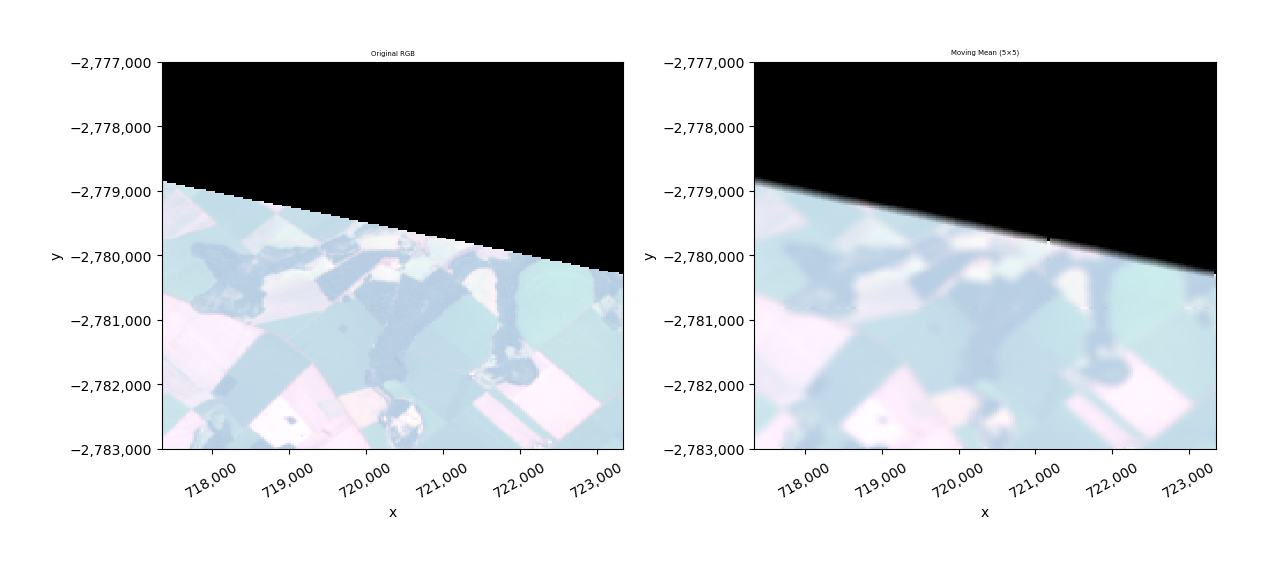

In [2]:
with gw.config.update(ref_bounds=BOUNDS):
    with gw.open(l8_224078_20200518, chunks=128, nodata=0) as src:
        result_mean = src.gw.moving(stat='mean', w=5, nodata=0)
        result_mean = result_mean.where(src != 0)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        src.sel(band=[3, 2, 1]).gw.imshow(mask=True, nodata=0, robust=True, ax=axes[0])
        axes[0].set_title('Original RGB')
        result_mean.sel(band=[3, 2, 1]).gw.imshow(mask=True, nodata=0, robust=True, ax=axes[1])
        axes[1].set_title('Moving Mean (5×5)')
        plt.tight_layout()
        plt.show()

## Comparing Window Sizes

Larger windows produce stronger smoothing. Let's compare 3×3, 7×7, and 11×11 windows.

Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS


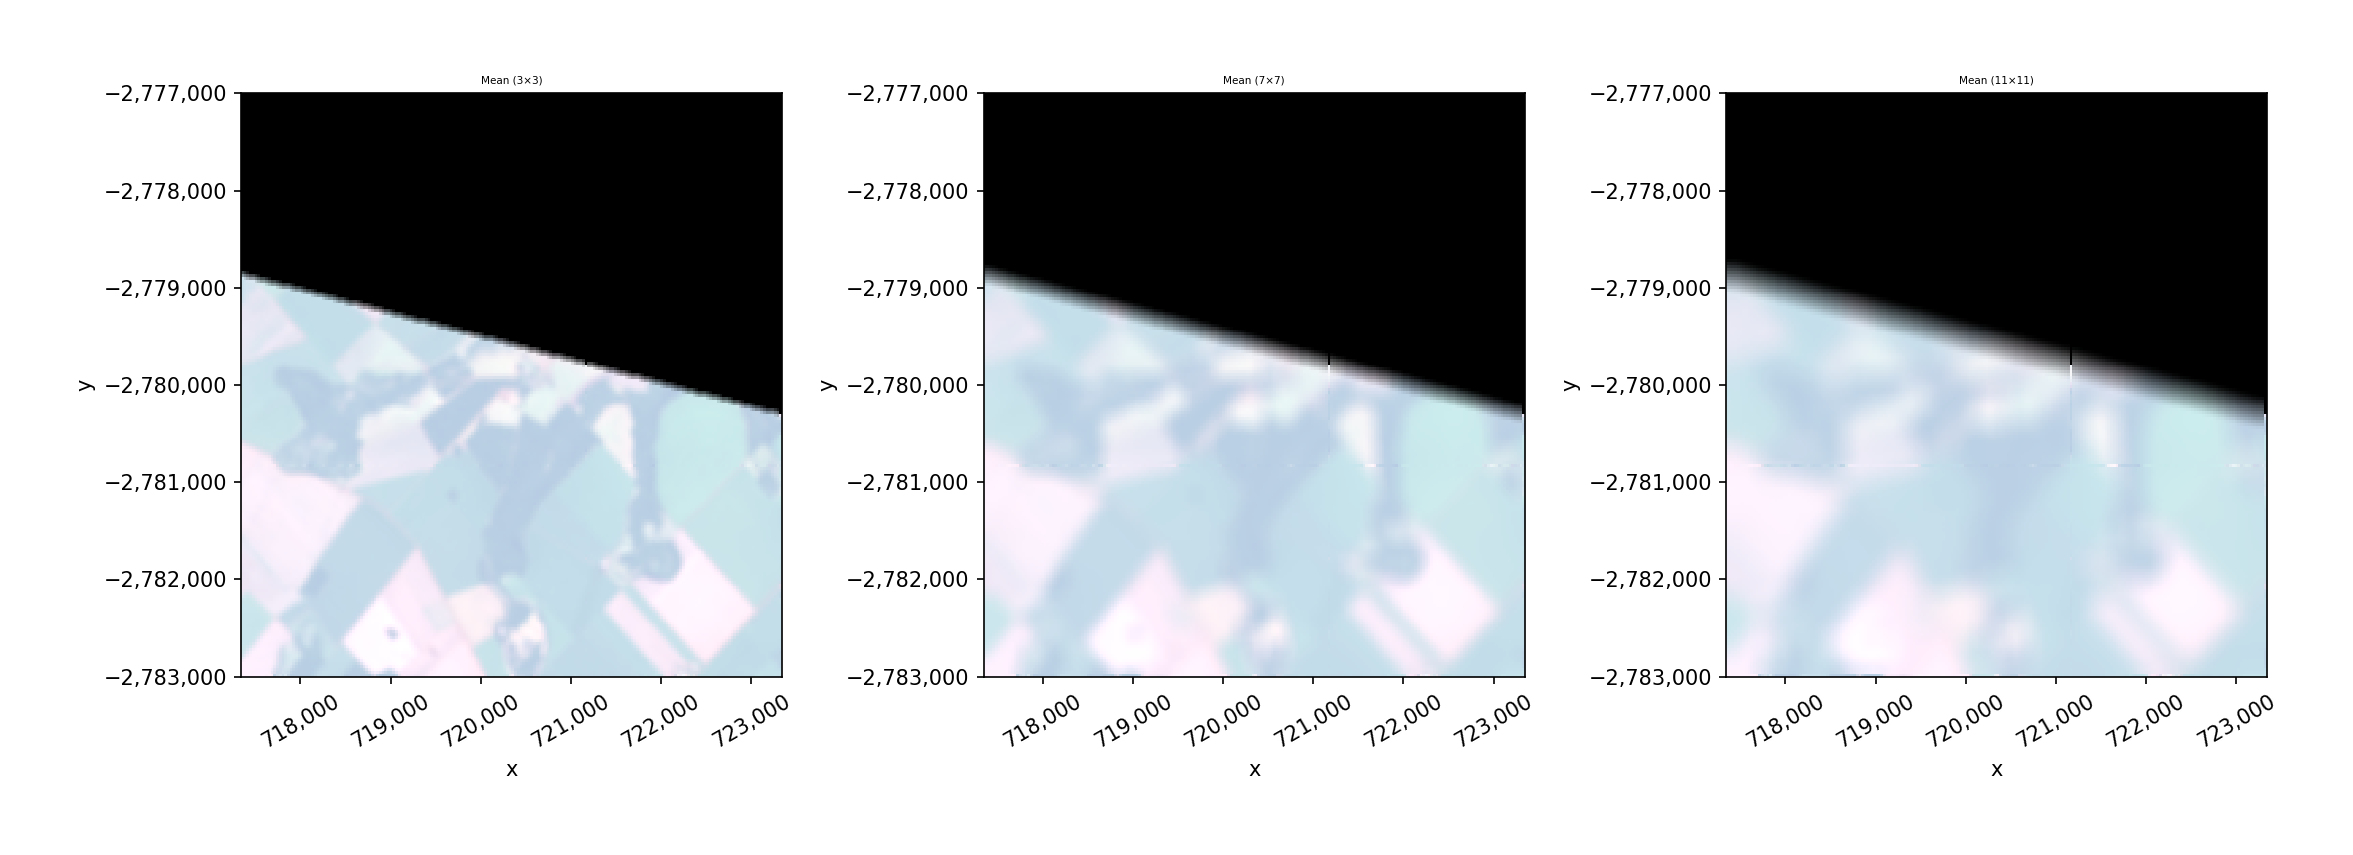

In [3]:
with gw.config.update(ref_bounds=BOUNDS):
    with gw.open(l8_224078_20200518, chunks=128, nodata=0) as src:
        sizes = [3, 7, 11]
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        for ax, w in zip(axes, sizes):
            result = src.gw.moving(stat='mean', w=w, nodata=0)
            result = result.where(src != 0)
            result.sel(band=[3, 2, 1]).gw.imshow(mask=True, nodata=0, robust=True, ax=ax)
            ax.set_title(f'Mean ({w}×{w})')

        plt.tight_layout()
        plt.show()

## Different Statistics

Beyond the mean, you can compute standard deviation (texture), min/max (morphological-style ops), and variance within the moving window.

Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support

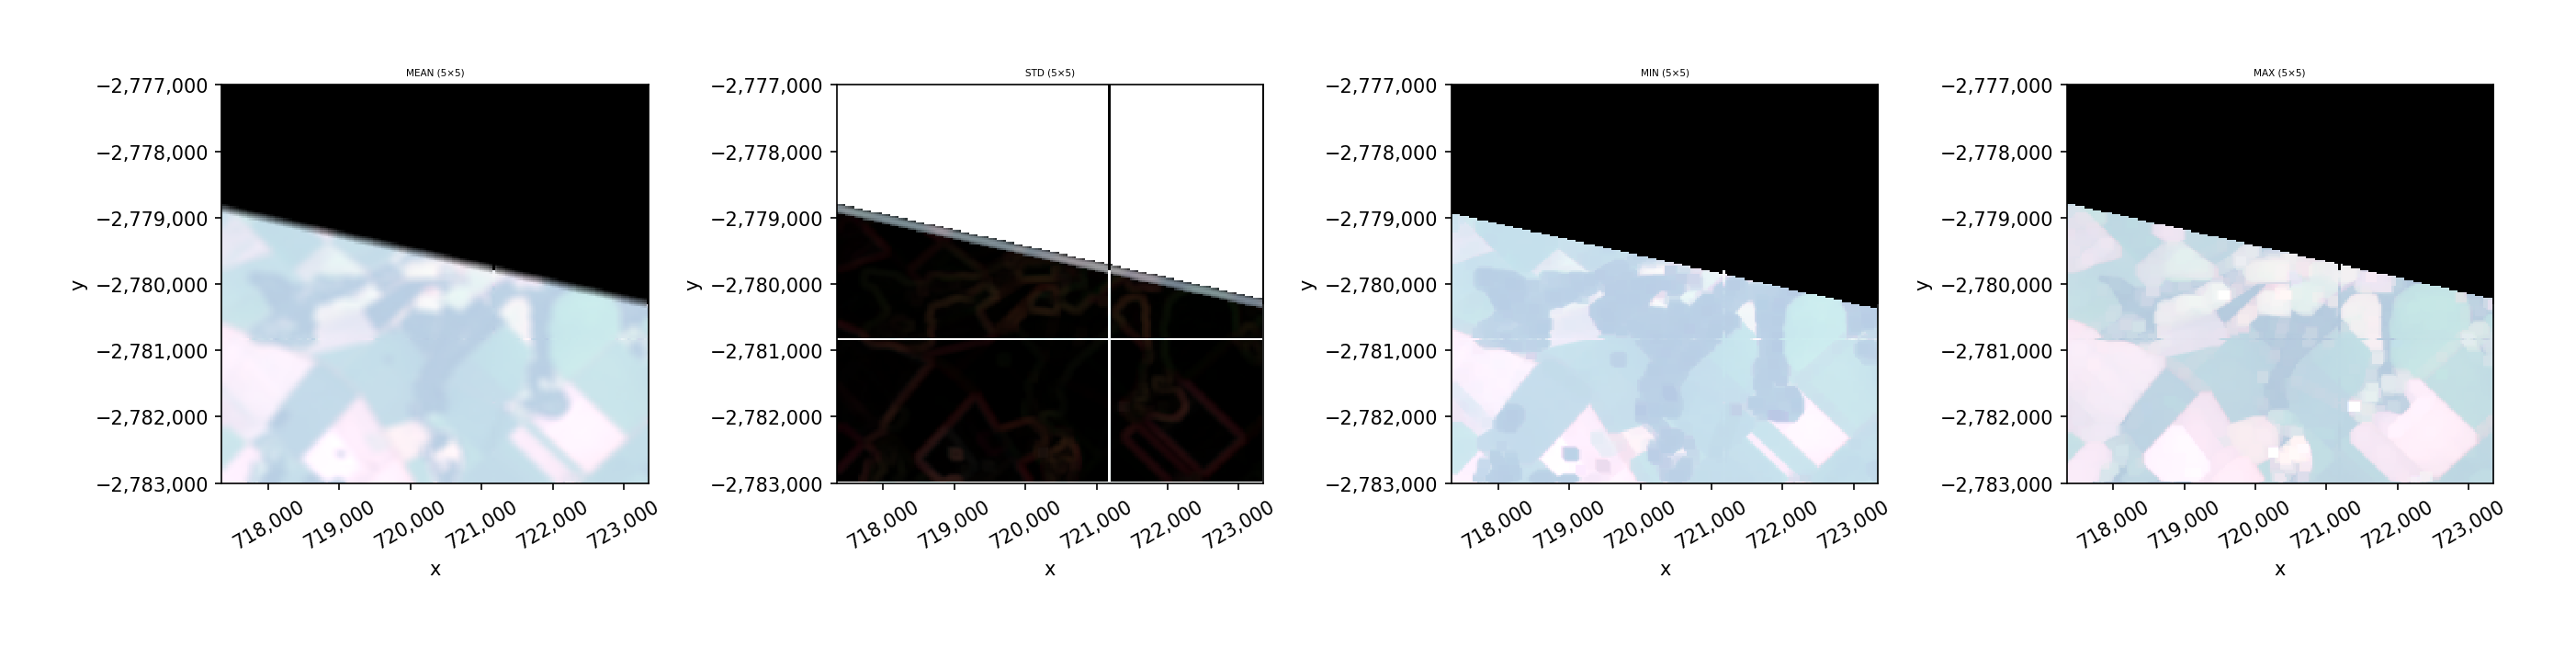

In [4]:
with gw.config.update(ref_bounds=BOUNDS):
    with gw.open(l8_224078_20200518, chunks=128, nodata=0) as src:
        stats = ['mean', 'std', 'min', 'max']
        fig, axes = plt.subplots(1, 4, figsize=(18, 4))

        for ax, stat in zip(axes, stats):
            result = src.gw.moving(stat=stat, w=5, nodata=0)
            result = result.where(src != 0)
            result.sel(band=[3, 2, 1]).gw.imshow(mask=True, nodata=0, robust=True, ax=ax)
            ax.set_title(f'{stat.upper()} (5×5)')

        plt.tight_layout()
        plt.show()

## Percentile Filter

Use `stat='perc'` with the `perc` parameter to compute a specific percentile within the window. This is useful for robust smoothing (e.g., median with `perc=50`) or for highlighting bright/dark features.

Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS


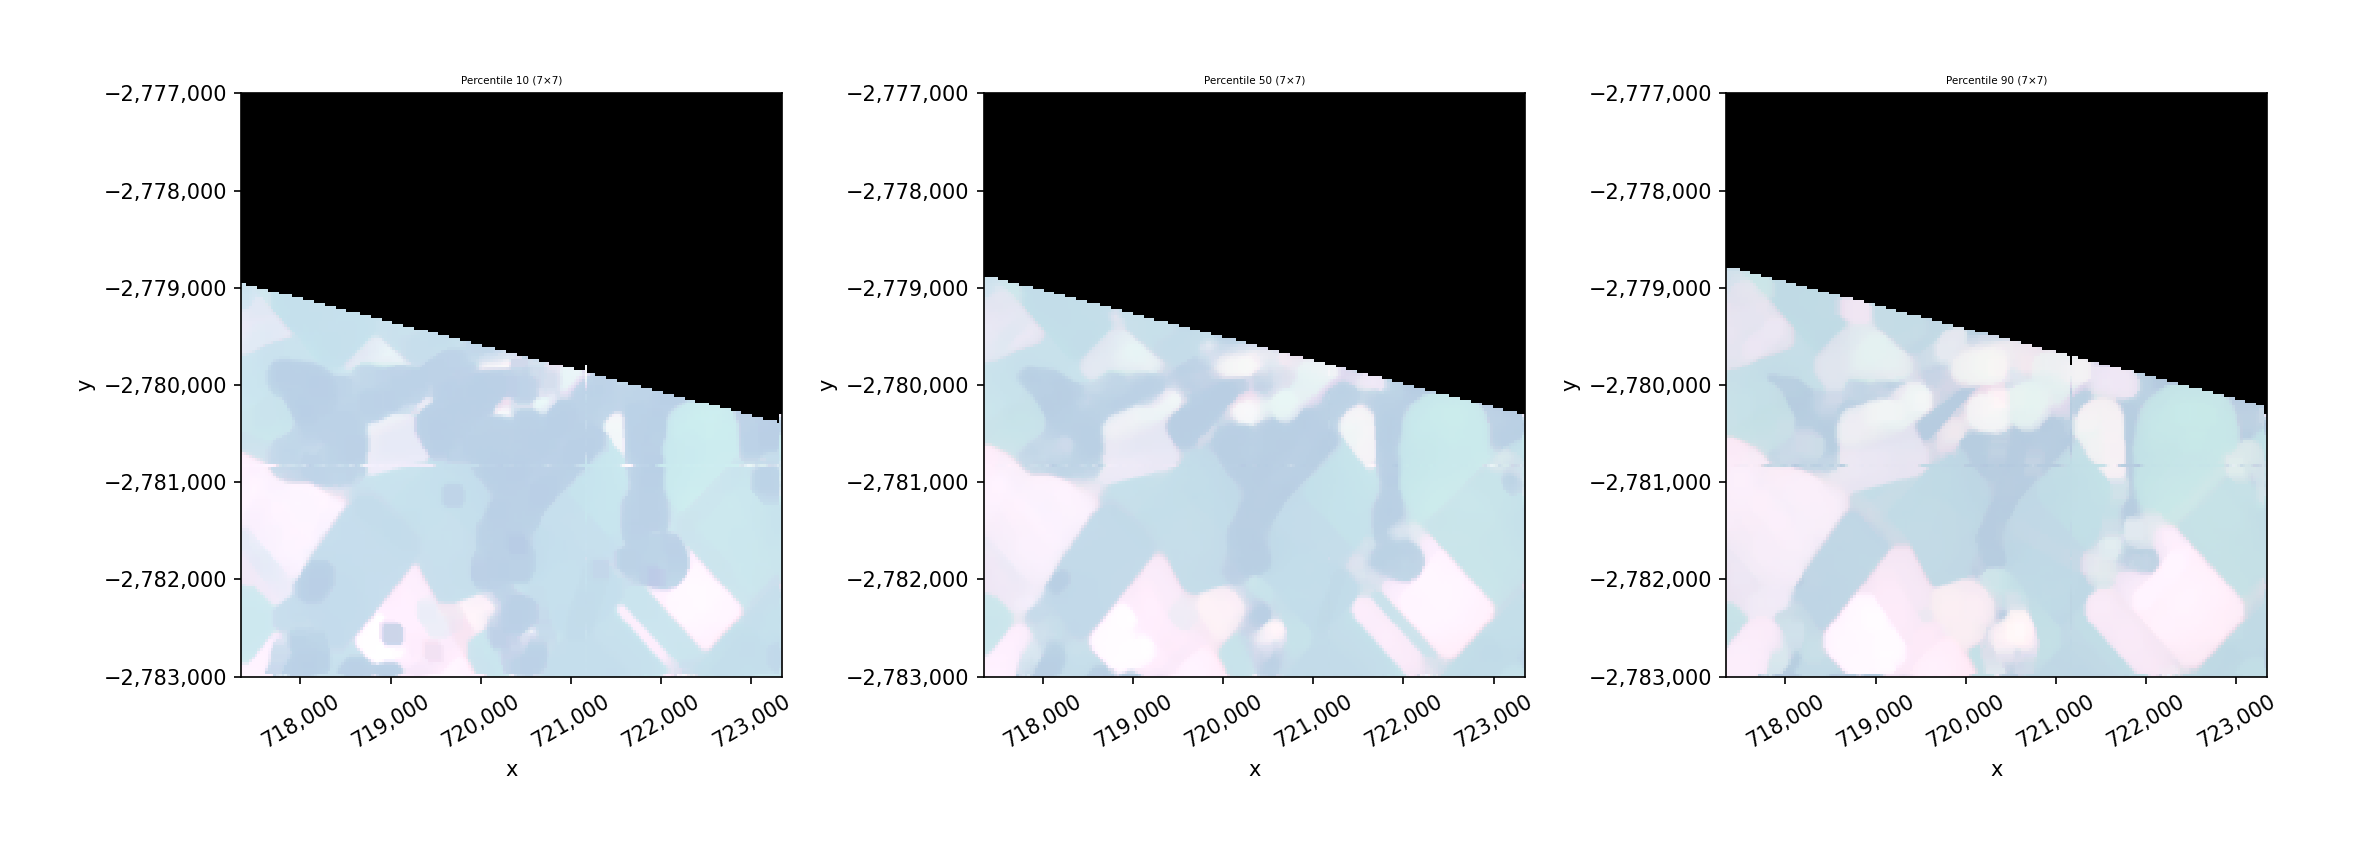

In [5]:
with gw.config.update(ref_bounds=BOUNDS):
    with gw.open(l8_224078_20200518, chunks=128, nodata=0) as src:
        percentiles = [10, 50, 90]
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        for ax, perc in zip(axes, percentiles):
            result = src.gw.moving(stat='perc', perc=perc, w=7, nodata=0)
            result = result.where(src != 0)
            result.sel(band=[3, 2, 1]).gw.imshow(mask=True, nodata=0, robust=True, ax=ax)
            ax.set_title(f'Percentile {perc} (7×7)')

        plt.tight_layout()
        plt.show()

## Distance-Weighted Moving Window

Setting `weights=True` weights each pixel by its distance from the window center, giving more influence to nearby pixels. This produces a smoother result similar to a Gaussian-like filter.

Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS


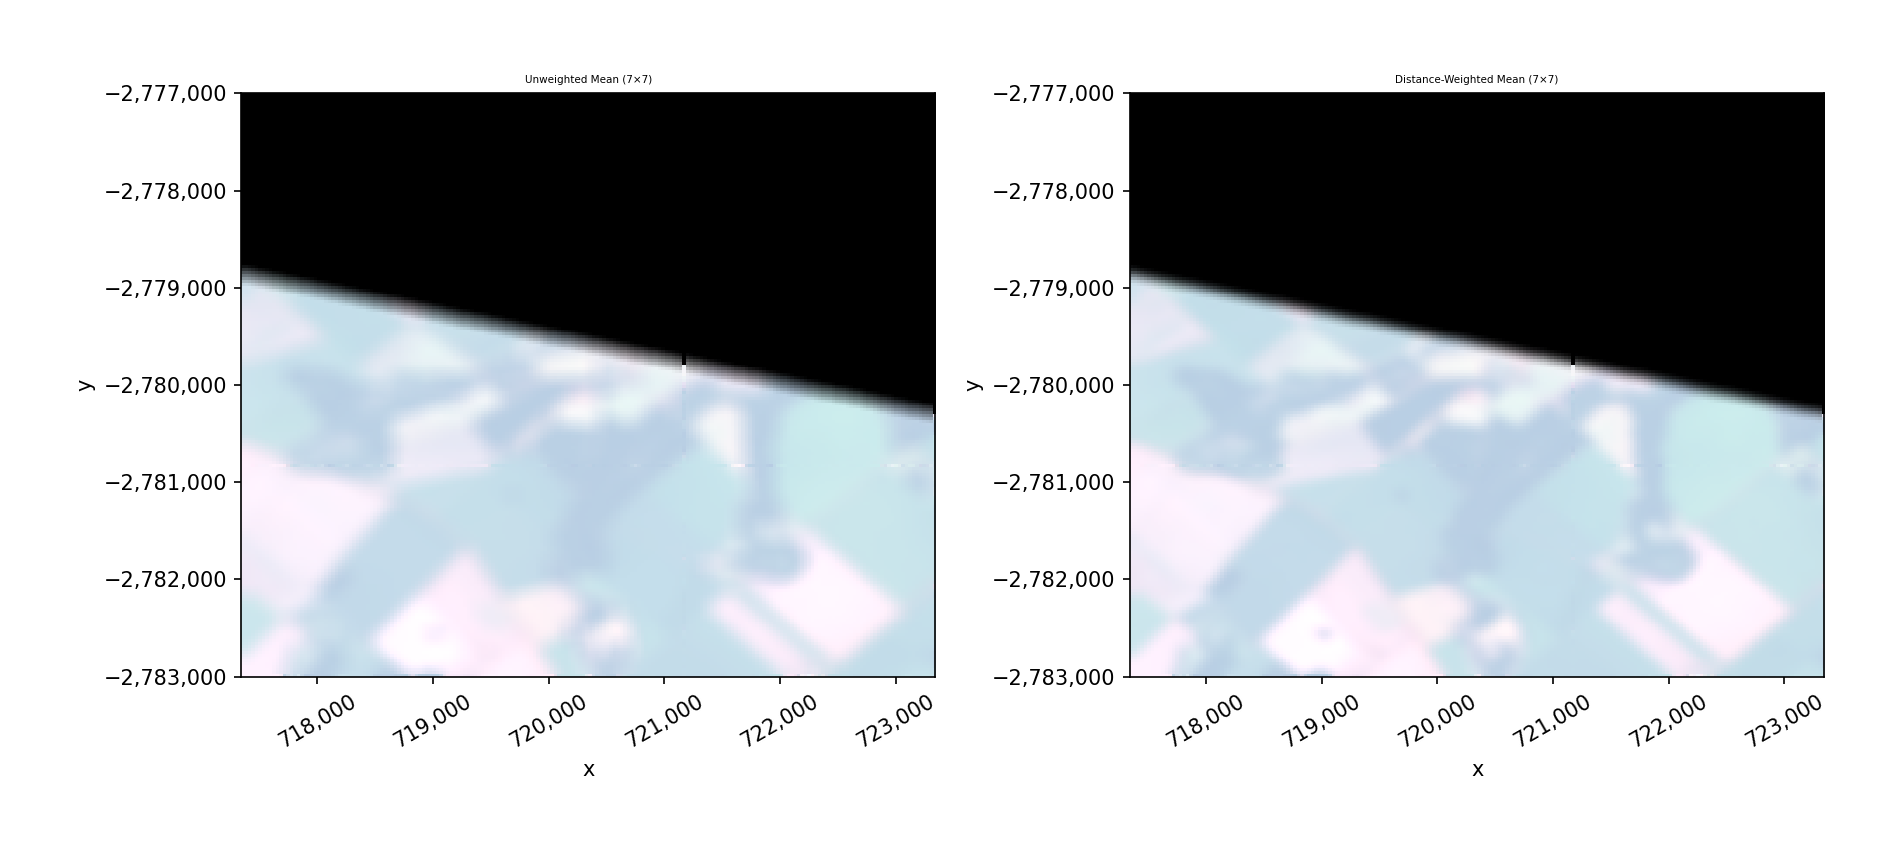

In [6]:
with gw.config.update(ref_bounds=BOUNDS):
    with gw.open(l8_224078_20200518, chunks=128, nodata=0) as src:
        result_unweighted = src.gw.moving(stat='mean', w=7, nodata=0)
        result_unweighted = result_unweighted.where(src != 0)
        result_weighted = src.gw.moving(stat='mean', w=7, nodata=0, weights=True)
        result_weighted = result_weighted.where(src != 0)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        result_unweighted.sel(band=[3, 2, 1]).gw.imshow(mask=True, nodata=0, robust=True, ax=axes[0])
        axes[0].set_title('Unweighted Mean (7×7)')
        result_weighted.sel(band=[3, 2, 1]).gw.imshow(mask=True, nodata=0, robust=True, ax=axes[1])
        axes[1].set_title('Distance-Weighted Mean (7×7)')
        plt.tight_layout()
        plt.show()

## Saving Results

Moving window results are lazy dask arrays. Use `.gw.save()` to write to disk or `.compute()` to load into memory.

In [7]:
with gw.config.update(ref_bounds=BOUNDS):
    with gw.open(l8_224078_20200518, chunks=128) as src:
        result = src.gw.moving(stat='mean', w=5, nodata=0)

        # Compute into memory
        result_computed = result.compute()
        print(f"Shape: {result_computed.shape}")
        print(f"Dtype: {result_computed.dtype}")

        # Save to file (uncomment to write)
        # result.gw.save('smoothed_output.tif', overwrite=True)

Shape: (3, 200, 200)
Dtype: float64


Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
